# Applying PCA

## PCA with an RBF SVM Classifier
This section trains a SVM classifier with a Gaussian RBF kernel on the MNIST training data (the first 60,000 observations). Use the default arguments for the classifier. Take the first 10,000 observations as the training set given by `X_train_red` and `y_train_red` in the code below. Time training using `%time` and report the accuracy of the trained model on the test set (the last 10,000 observations of MNIST). Now, use PCA on the original training set (60,0000 observations) to find principal components with an explained variance ratio of 60%. Retrain the SVM classifier using these principal components instead of the original features. Time the training and accuracy on the test set. Comment on whether PCA helped or not. The data order is preserved, and no standard scaler is used.


In [1]:
import numpy as np

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False, cache=True)
mnist.target = mnist.target.astype(np.int8)
X_train = mnist["data"][:60000]
X_test  = mnist["data"][60000:]
y_train = mnist["target"][:60000]
y_test  = mnist["target"][60000:]
X_train_red = mnist["data"][:10000]
y_train_red = mnist["target"][:10000]

**Implementation:**


In [2]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

In [3]:
# SVM without PCA
svm_clf = SVC(kernel="rbf")

%time svm_clf.fit(X_train_red, y_train_red)

y_pred = svm_clf.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred)

print("SVM accuracy without PCA:", svm_acc)

CPU times: total: 3.36 s
Wall time: 3.52 s
SVM accuracy without PCA: 0.9594


In [4]:
# PCA
pca_60 = PCA(n_components=0.60)
pca_60.fit(X_train)

print("Number of principal components:", pca_60.n_components_)
print("Explained variance ratio:", pca_60.explained_variance_ratio_.sum())

Number of principal components: 17
Explained variance ratio: 0.6074124552802456


In [5]:
# Transform training and test sets using PCA
X_train_red_pca = pca_60.transform(X_train_red)
X_test_pca = pca_60.transform(X_test)

# SVM with PCA
svm_clf_pca = SVC(kernel="rbf")

%time svm_clf_pca.fit(X_train_red_pca, y_train_red)

y_pred_pca = svm_clf_pca.predict(X_test_pca)
svm_pca_acc = accuracy_score(y_test, y_pred_pca)

print("SVM accuracy with PCA:", svm_pca_acc)

CPU times: total: 344 ms
Wall time: 363 ms
SVM accuracy with PCA: 0.956


### PCA SVM Result Notes
For the SVM classifier, PCA was helpful in this case. Without PCA, the test accuracy was **0.9594**. After applying PCA and keeping 60% of the variance, the model used only **17 principal components** and still achieved a test accuracy of **0.956**.

The accuracy decreased only slightly, from **0.9594** to **0.956**, which is a difference of only **0.0034**. This means PCA greatly reduced the number of features while preserving almost the same predictive performance.

Therefore, PCA is useful here because it reduces the dimensionality of the data substantially with only a very small loss in accuracy. If the training time with PCA was shorter, then PCA helped make the SVM model more efficient.


## PCA with a Random Forest Classifier
Repeat (a) using a random forest classifier instead of the SVM classifier and comment on the result. Use `random_state=42` in the classifier and use the default for the other arguments. `n_jobs=-1` can be used.


**Implementation:**


In [8]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest without PCA
rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1)

%time rf_clf.fit(X_train_red, y_train_red)

y_pred_rf = rf_clf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest accuracy without PCA:", rf_acc)

CPU times: total: 4.45 s
Wall time: 355 ms
Random Forest accuracy without PCA: 0.9504


In [9]:
# Random Forest with PCA
rf_clf_pca = RandomForestClassifier(random_state=42, n_jobs=-1)

%time rf_clf_pca.fit(X_train_red_pca, y_train_red)

y_pred_rf_pca = rf_clf_pca.predict(X_test_pca)
rf_pca_acc = accuracy_score(y_test, y_pred_rf_pca)

print("Random Forest accuracy with PCA:", rf_pca_acc)

CPU times: total: 3.64 s
Wall time: 282 ms
Random Forest accuracy with PCA: 0.918


### PCA Random Forest Result Notes
For the Random Forest classifier, PCA was **not very helpful** in this case. Without PCA, the test accuracy was **0.9504**. After applying PCA and keeping 60% of the variance, the model used only **17 principal components**, but the test accuracy dropped to **0.918**.

The accuracy decreased from **0.9504** to **0.918**, which is a drop of **0.0324**. This decrease is much larger than the accuracy drop for the SVM model.

Therefore, PCA **did not** improve the performance of the Random Forest classifier in this problem. One possible reason is that Random Forest models work well with the original pixel features, but PCA transforms the original features into new linear combinations. These transformed features may make it harder for the decision trees to find useful splits.

Overall, PCA reduced the dimensionality, but it caused a noticeable loss in accuracy. So, for Random Forest, PCA was not useful here unless the main goal was only to reduce training time.


# Visualizing Dimensionality Reduction

## t-SNE Visualization of MNIST
This section loads the MNIST dataset and takes only the first 5,000 observations as `X` and `y`. The nonlinear dimensionality reduction technique **t-SNE** reduces this subset of the MNIST dataset down to 2 dimensions. Include the argument `random_state=42`. Measure how long it took to reduce the dimensionality, this will be used in (b) below. Plot a scatterplot of the outcome of t-SNE. Use 10 different colors to represent each image's target class and plot scaled-down versions of the digit images themselves. The visualization will be too cluttered if the image is drawn for every observation, so it is useful to either draw a random sample or plot an instance only if no other instance has already been plotted at a close distance. It is useful to get a nice visualization of different classes and some of the digit images in them. See the textbook's Jupyter notebook for the code. Use the plot to comment on which classes are easily identified and which ones can be hard to distinguish.

Hint: See the solution of Chapter 8, the related textbook example in this [Jupyter notebook](https://github.com/ageron/handson-ml3/blob/main/08_dimensionality_reduction.ipynb) on the textbook website to see how to implement t-SNE and produce these plots using the `plot_digits()` function.


**Implementation:**


In [42]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import time

# first 5000 observations
X = mnist["data"][:5000]
y = mnist["target"][:5000]

# Apply t-SNE to reduce to 2 dimensions
tsne = TSNE(n_components=2, random_state=42)

start_time = time.time()
X_tsne = tsne.fit_transform(X)
tsne_time = time.time() - start_time

print("t-SNE time:", tsne_time, "seconds")

t-SNE time: 7.7043867111206055 seconds


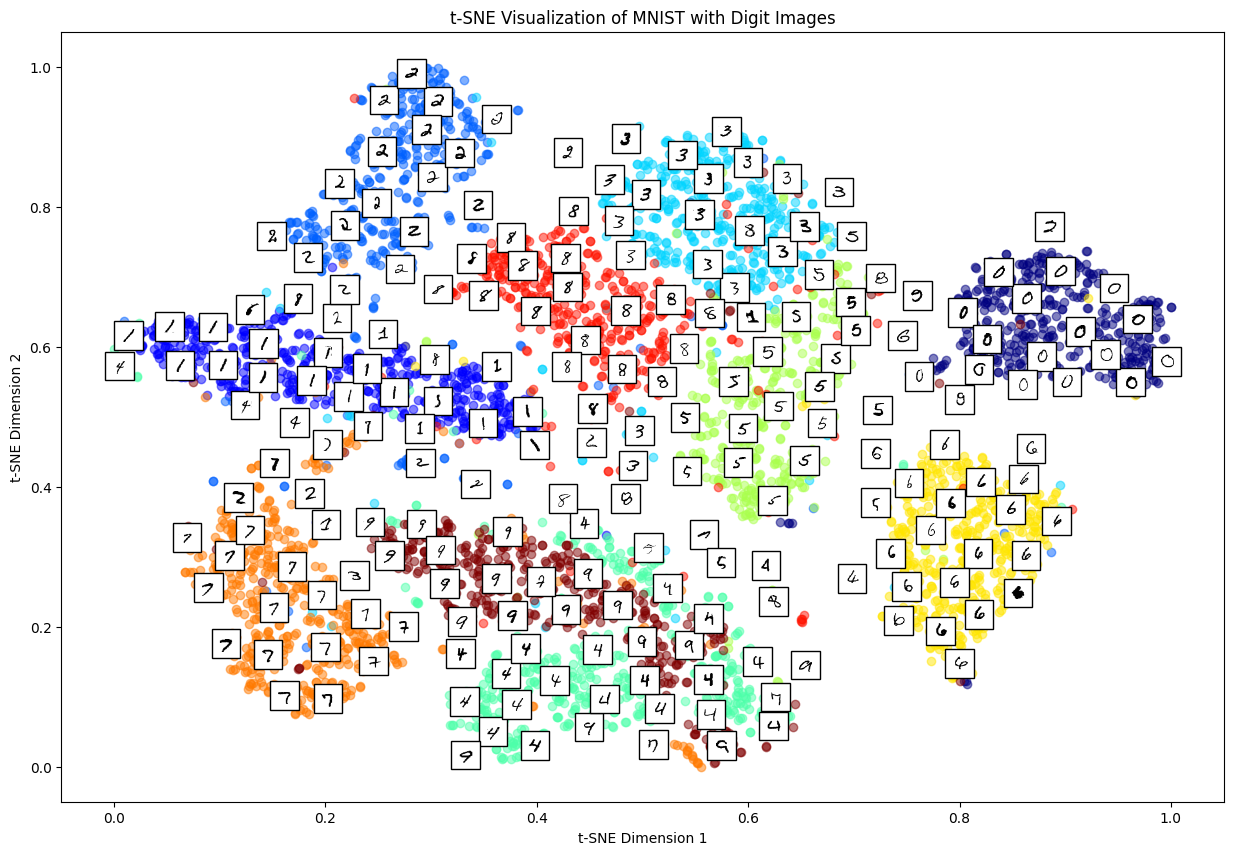

In [60]:
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from sklearn.preprocessing import MinMaxScaler

def plot_digits(X, y, min_distance=0.04, images=None, figsize=(15, 10)):
    # Scale the 2D coordinates to the range 0 to 1
    X_normalized = MinMaxScaler().fit_transform(X)
    
    # Store the coordinates of images already plotted
    neighbors = np.array([[10., 10.]])
    
    plt.figure(figsize=figsize)
    cmap = plt.cm.jet
    digits = np.unique(y.astype(int))
    
    # Plot each digit class with a different color
    for digit in digits:
        plt.scatter(
            X_normalized[y.astype(int) == digit, 0],
            X_normalized[y.astype(int) == digit, 1],
            c=[cmap(float(digit) / 9)],
            alpha=0.5
        )
    
    ax = plt.gca()
    
    # Add digit images only if they are far enough apart
    for index, image_coord in enumerate(X_normalized):
        closest_distance = np.linalg.norm(neighbors - image_coord, axis=1).min()
        
        if closest_distance > min_distance:
            neighbors = np.r_[neighbors, [image_coord]]
            
            if images is None:
                plt.text(
                    image_coord[0],
                    image_coord[1],
                    str(int(y[index])),
                    color=cmap(float(int(y[index])) / 9),
                    fontdict={"weight": "bold", "size": 16}
                )
            else:
                image = images[index].reshape(28, 28)
                imagebox = AnnotationBbox(
                    OffsetImage(image, cmap="binary", zoom=0.45),
                    image_coord
                )
                ax.add_artist(imagebox)
    
    plt.title("t-SNE Visualization of MNIST with Digit Images")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

plot_digits(X_tsne, y, min_distance=0.04, images=X)

## Comparing PCA, LLE, and PCA + t-SNE
This comparison uses other dimensionality reduction methods. The comparison includes:

* Regular PCA to reduce to 2 dimensions.
* LLE to reduce to 2 dimensions.
* First apply PCA with an explained variance ratio of 95%, then apply t-SNE to reduce to 2 dimensions.

For each algorithm, the notebook includes the argument `random_state=42`, reports the dimensionality-reduction runtime, and provides a 2D plot of the results. The comparison also includes the t-SNE result from the previous section.


**Implementation:**


### Regular PCA to Two Dimensions


In [44]:
from sklearn.decomposition import PCA
from sklearn.manifold import LocallyLinearEmbedding

# Regular PCA reduced to 2 dimensions
pca_2d = PCA(n_components=2, random_state=42)

start_time = time.time()
X_pca_2d = pca_2d.fit_transform(X)
pca_time = time.time() - start_time

print("PCA time:", pca_time, "seconds")

PCA time: 0.04551434516906738 seconds


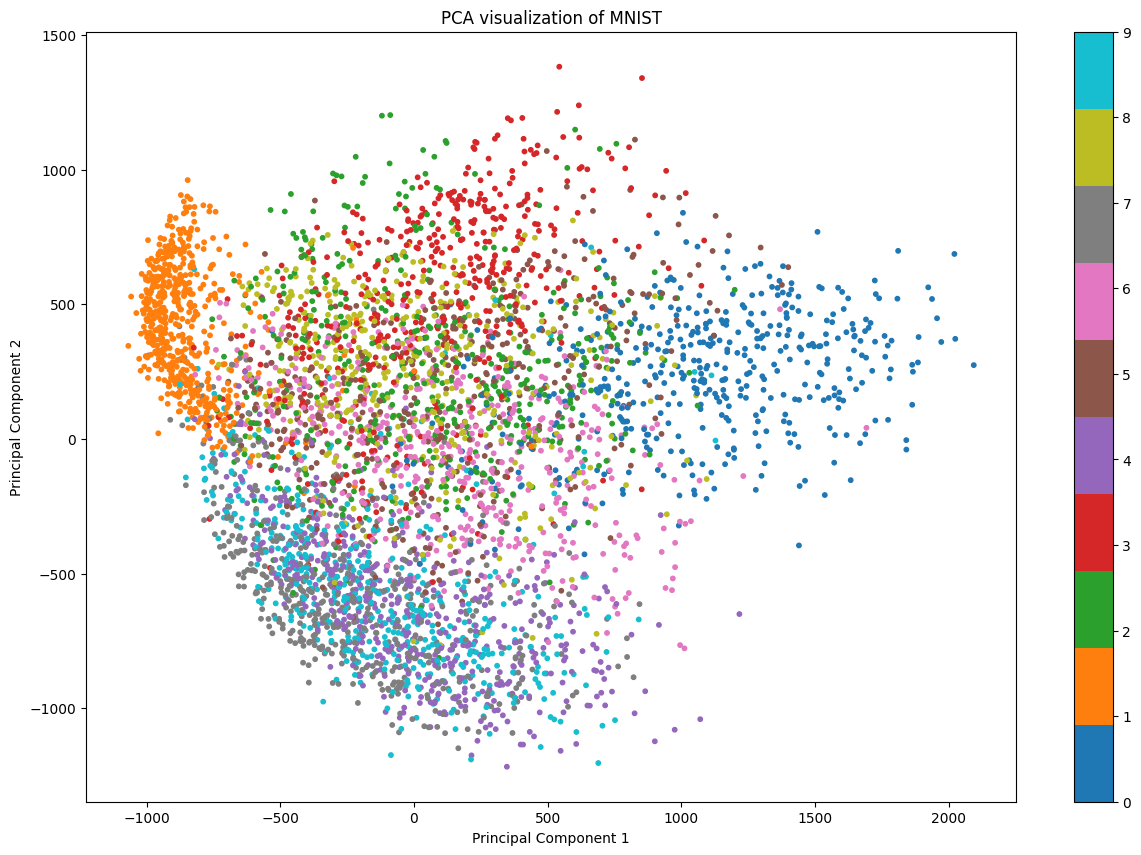

In [61]:
plt.figure(figsize=(15, 10))
scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y,
    cmap="tab10",
    s=10
)

plt.colorbar(scatter, ticks=range(10))
plt.title("PCA visualization of MNIST")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

### LLE to Two Dimensions


In [47]:
lle = LocallyLinearEmbedding(n_components=2, random_state=42)

start_time = time.time()
X_lle_2d = lle.fit_transform(X)
lle_time = time.time() - start_time

print("LLE time:", lle_time, "seconds")

LLE time: 1.0483613014221191 seconds


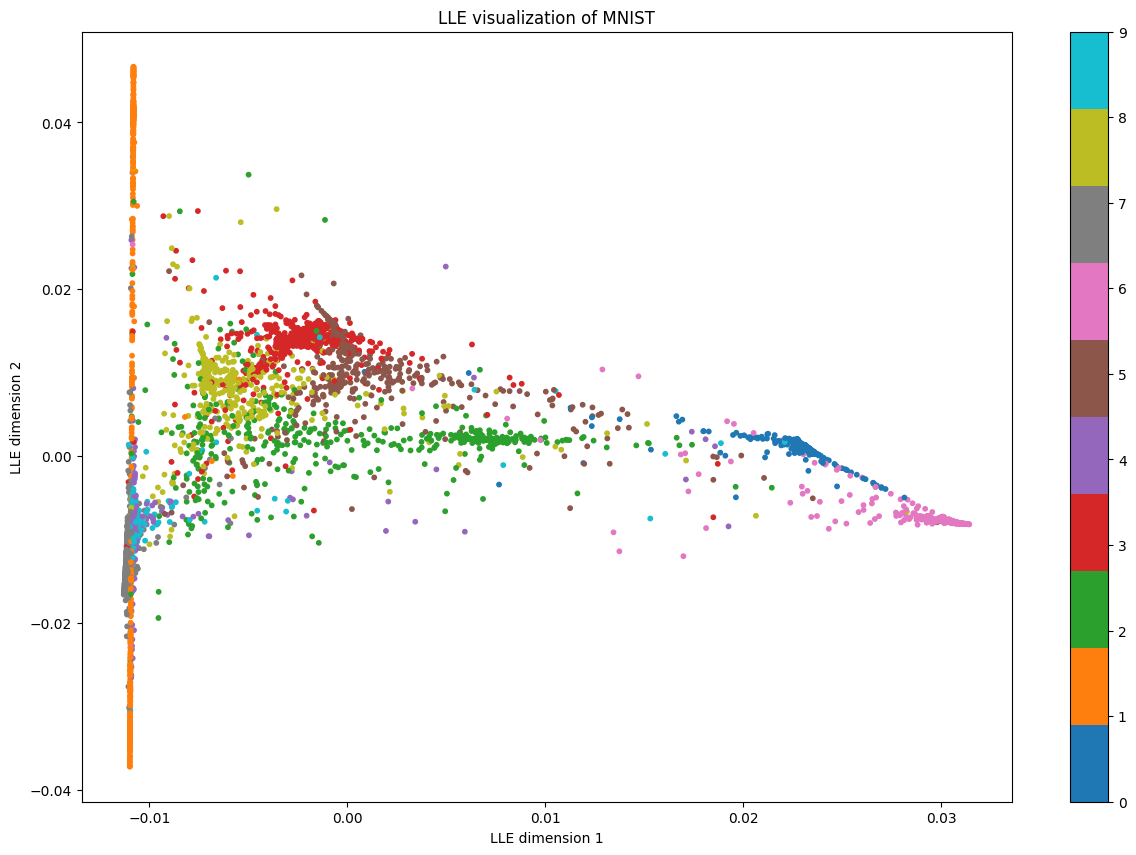

In [62]:
plt.figure(figsize=(15, 10))
scatter = plt.scatter(
    X_lle_2d[:, 0],
    X_lle_2d[:, 1],
    c=y,
    cmap="tab10",
    s=10
)

plt.colorbar(scatter, ticks=range(10))
plt.title("LLE visualization of MNIST")
plt.xlabel("LLE dimension 1")
plt.ylabel("LLE dimension 2")
plt.show()

### PCA 95% and t-SNE to Two Dimensions


In [54]:
# PCA with an explained variance ratio of 95%
pca_95 = PCA(n_components=0.95, random_state=42)

start_time = time.time()
X_pca_95 = pca_95.fit_transform(X)
pca_95_time = time.time() - start_time

print("PCA 95% time:", pca_95_time, "seconds")

PCA 95% time: 0.36835622787475586 seconds


In [55]:
# t-SNE to reduce to 2 dimensions
tsne_after_pca = TSNE(n_components=2, random_state=42)

start_time = time.time()
X_pca_tsne_2d = tsne_after_pca.fit_transform(X_pca_95)
pca_tsne_time = time.time() - start_time

total_pca_tsne_time = pca_95_time + pca_tsne_time

print("t-SNE after PCA time:", pca_tsne_time, "seconds")
print("Total time:", total_pca_tsne_time, "seconds")

t-SNE after PCA time: 7.467536926269531 seconds
Total time: 7.835893154144287 seconds


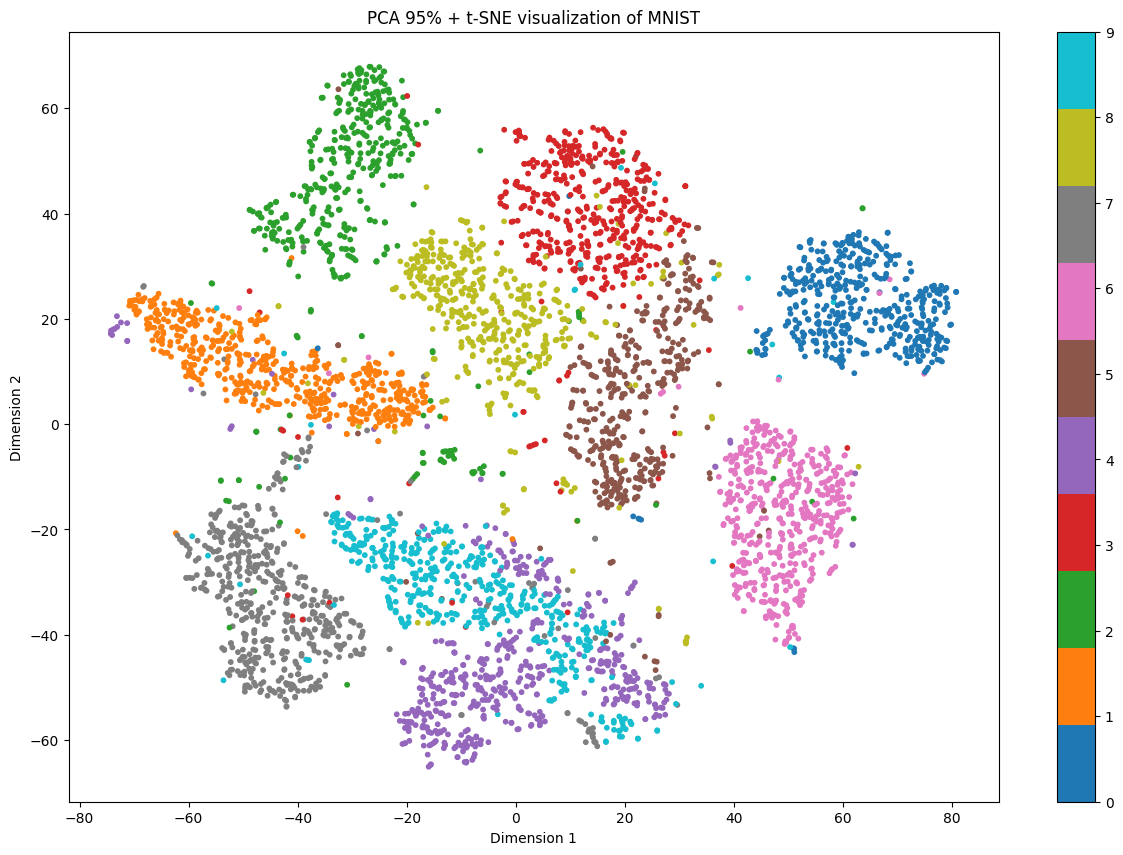

: 

In [ ]:
plt.figure(figsize=(15, 10))
scatter = plt.scatter(
    X_pca_tsne_2d[:, 0],
    X_pca_tsne_2d[:, 1],
    c=y,
    cmap="tab10",
    s=10
)

plt.colorbar(scatter, ticks=range(10))
plt.title("PCA 95% + t-SNE visualization of MNIST")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

### Dimensionality Reduction Comparison Notes
The running times for the dimensionality reduction methods were:

- **t-SNE:** 7.7044 seconds
- **PCA:** 0.0455 seconds
- **LLE:** 1.0484 seconds
- **PCA 95% + t-SNE:** 7.8359 seconds

1. Based on the running times, **PCA was the fastest method**.

2. For the visualization quality, the **t-SNE-based methods produced the best plots**. The original t-SNE plot from 2(a) and the PCA 95% + t-SNE plot both separated the digit classes much more clearly than PCA and LLE.


# k-Means Clustering

Hint: It is helpful to read the solution of Chapter 9, the related Chapter 9 examples in this [Jupyter notebook](https://github.com/ageron/handson-ml3/blob/main/09_unsupervised_learning.ipynb).

## Face Clustering with PCA and k-Means

The classic Olivetti faces dataset contains 400 grayscale $64\times 64$ pixel images of faces. Each image is flattened to a 1D vector of size 4096. 40 different people were photographed (10 times each), and the task is to train a model that can predict which person is represented in each picture. Load the dataset and split it into a training set and a validation set using the code below. Since the dataset is quite small, stratified sampling is used to ensure that there are the same number of images per person in each set. There is no need to create a test set.


In [1]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import StratifiedShuffleSplit

data = fetch_olivetti_faces()
# Creating validation set
strat_split = StratifiedShuffleSplit(n_splits=1, test_size=120, random_state=42)
train_idx, val_idx = next(strat_split.split(data.data, data.target))
X_valid, y_valid = data.data[val_idx], data.target[val_idx]
# Creating training set
X_train, y_train = data.data[train_idx], data.target[train_idx]

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\Wilson\scikit_learn_data


Note that the dataset is already scaled between 0 and 1, so there is no need to use a standard scaler. Next, PCA is applied to the features with an explained variance ratio of 99%. The reduced features are then clustered with k-Means, where the argument `random_state=42` is included. To determine the number of clusters $k\in\{5,10,15,\dots,145\}$, (i) plot inertia, (ii) plot silhouette scores. Choose the number of clusters $k'$ based on (ii). Then (iii) plot silhouette diagrams where the number of clusters is 40 and $k'$, and explain which number of clusters is better. Finally, suppose we use $k'$ clusters, (iv) visualize the clusters by plotting the images in each cluster and comment on whether similar faces appear in each cluster.


**Implementation:**


In [3]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Apply PCA with 99% explained variance
pca = PCA(n_components=0.99, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)

In [4]:
# Try k-Means for different values of k
k_range = range(5, 150, 5)

inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_train_pca)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_pca, cluster_labels))

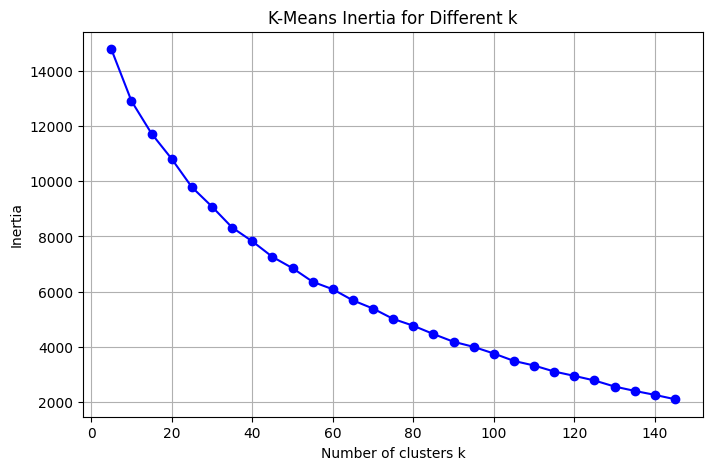

In [ ]:
# (i) Plot inertia
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, "bo-")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("K-Means Inertia for Different k")
plt.grid(True)
plt.show()

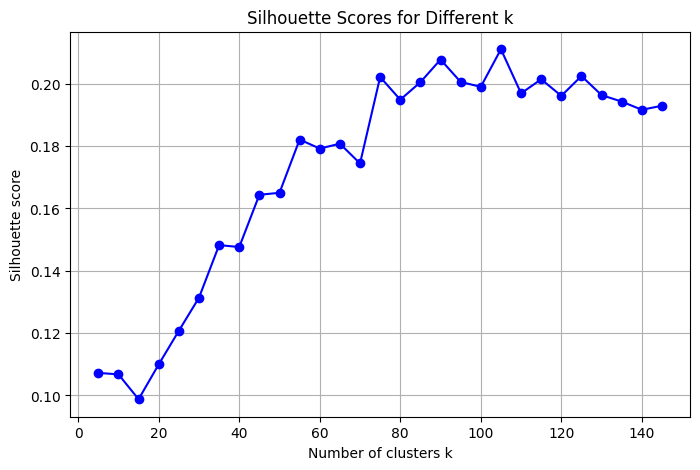

Best k based on silhouette score: 105
Best silhouette score: 0.2110873907804489


In [ ]:
# (ii Plot silhouette scores and choose best k

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, "bo-")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette Scores for Different k")
plt.grid(True)
plt.show()

best_k = list(k_range)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print("Best k based on silhouette score:", best_k)
print("Best silhouette score:", best_score)

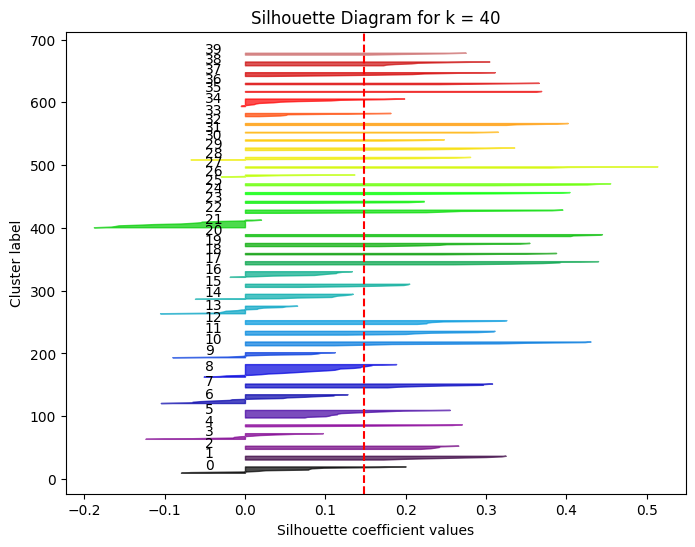

k = 40, silhouette score = 0.14761283993721008


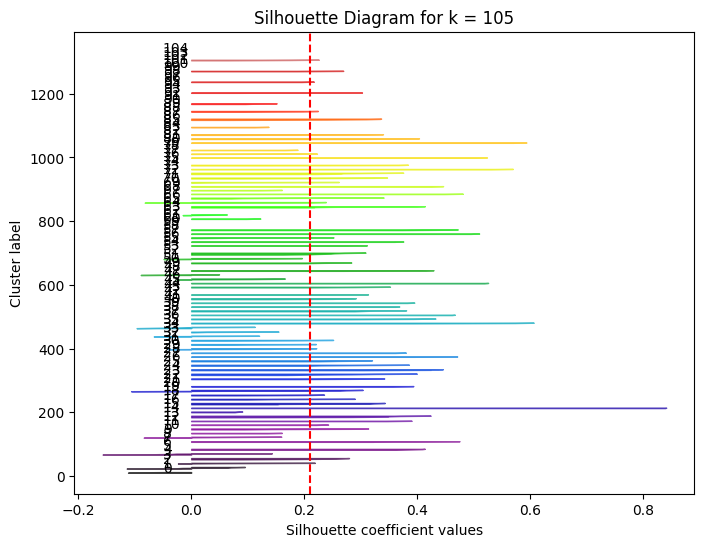

k = 105, silhouette score = 0.2110873907804489


In [7]:
# (iii) Plot silhouette diagrams for k = 40 and k = best_k

def plot_silhouette_diagram(X, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    
    silhouette_avg = silhouette_score(X, cluster_labels)
    sample_silhouette_values = silhouette_samples(X, cluster_labels)
    
    plt.figure(figsize=(8, 6))
    
    y_lower = 10
    
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / k)
        
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )
        
        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.xlabel("Silhouette coefficient values")
    plt.ylabel("Cluster label")
    plt.title(f"Silhouette Diagram for k = {k}")
    plt.show()
    
    print(f"k = {k}, silhouette score = {silhouette_avg}")

plot_silhouette_diagram(X_train_pca, 40)
plot_silhouette_diagram(X_train_pca, best_k)

The clustering result with **k = 105** is better than **k = 40** based on the silhouette diagrams.

For **k = 40**, the average silhouette score is lower, around **0.15**, and several clusters contain many samples with negative silhouette values. This suggests that some  may be assigned to the wrong clusters or that the clusters overlap.

For **k = 105**, the average silhouette score is higher, around **0.21**. More clusters have positive silhouette values, and some clusters show stronger separation from the others.

Therefore, based on the silhouette diagrams, **k = 105** is the better choice because it has a higher average silhouette score and better cluster separation.


In [ ]:
# (iv) Visualize faces in each cluster

# Fit final k-Means model using best_k
best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
best_cluster_labels = best_kmeans.fit_predict(X_train_pca)

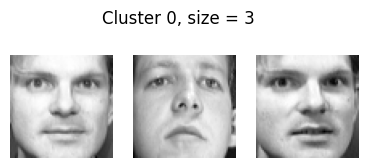

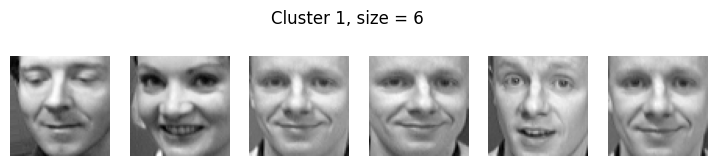

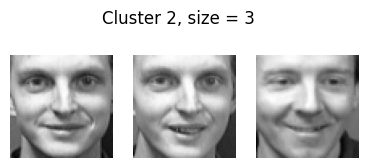

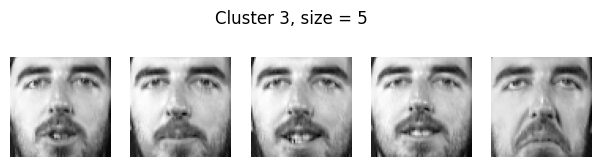

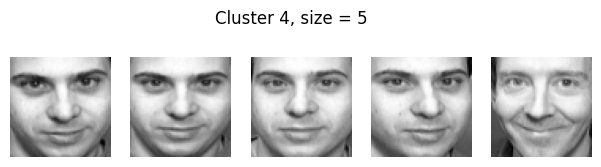

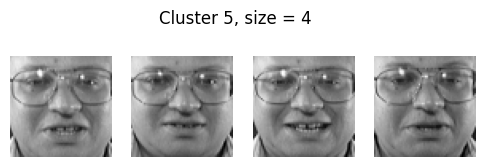

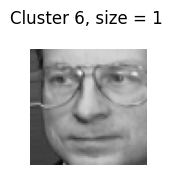

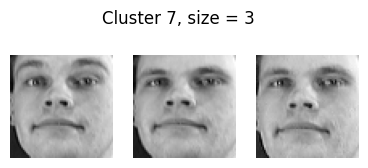

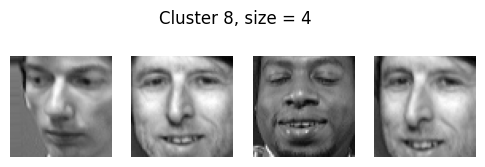

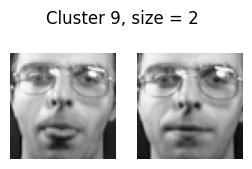

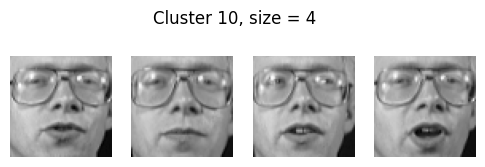

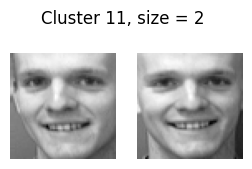

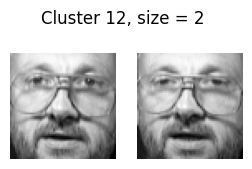

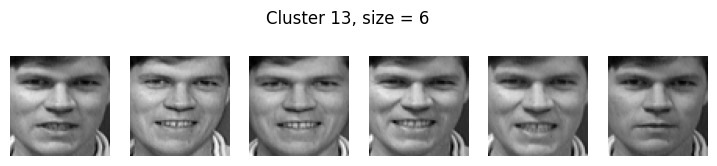

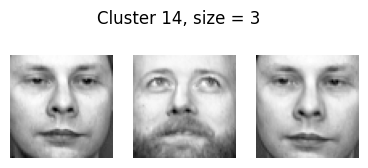

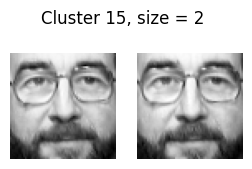

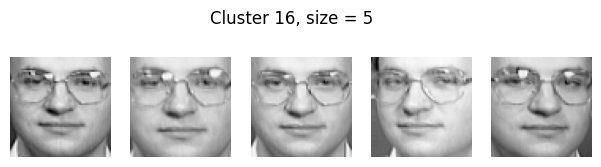

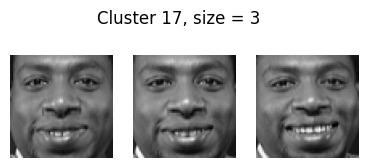

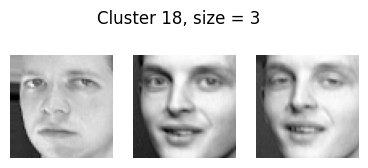

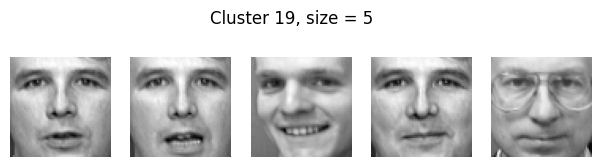

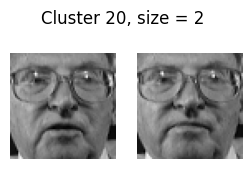

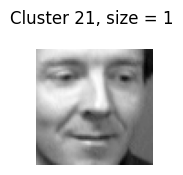

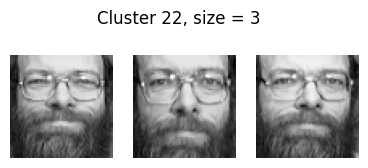

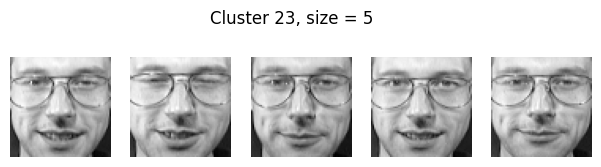

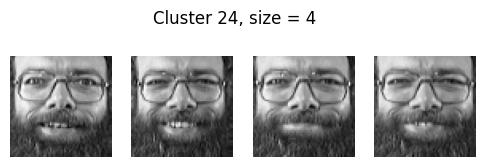

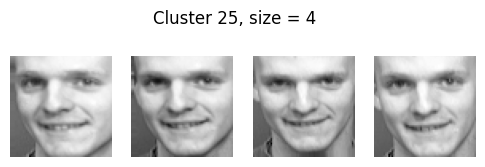

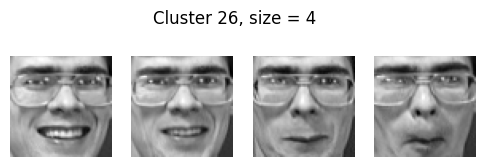

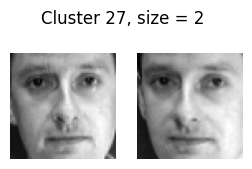

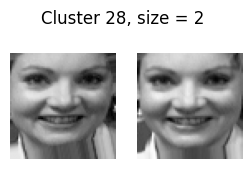

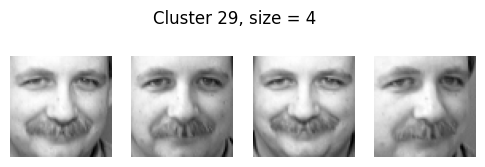

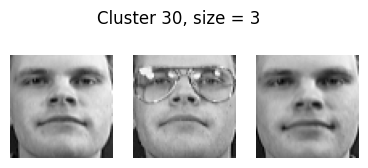

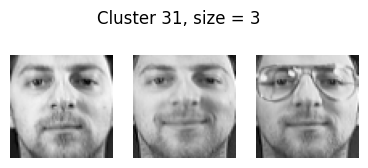

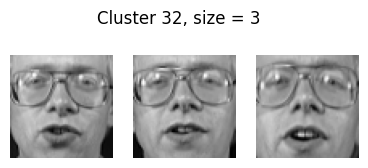

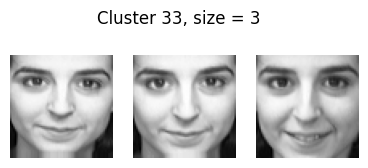

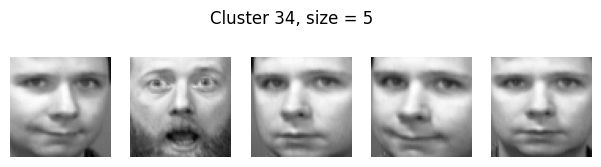

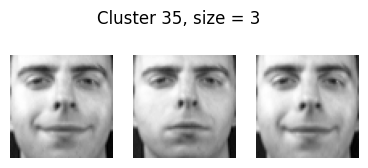

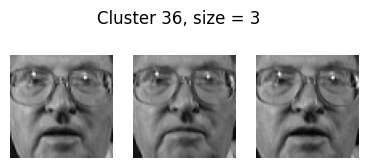

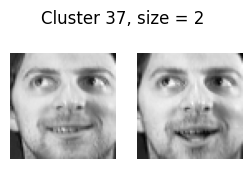

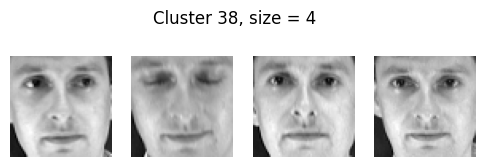

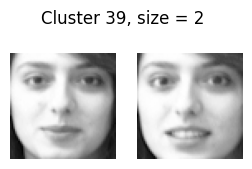

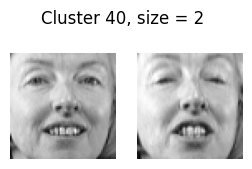

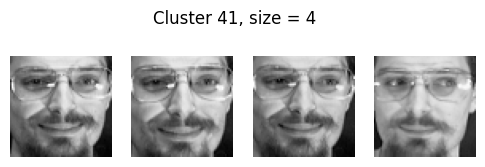

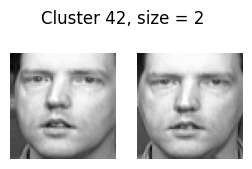

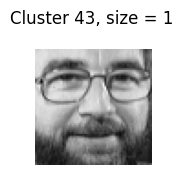

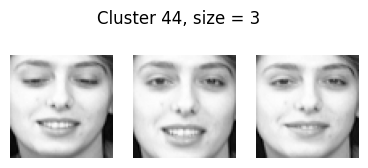

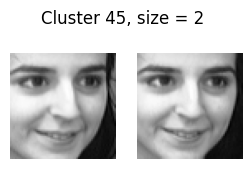

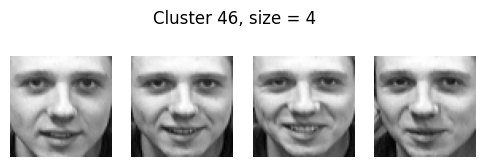

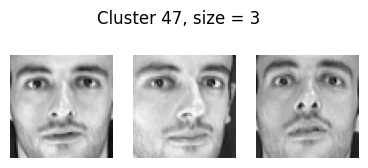

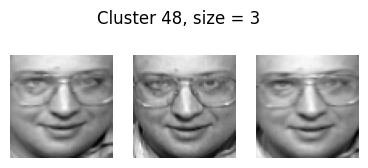

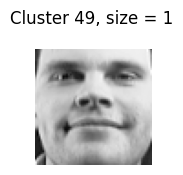

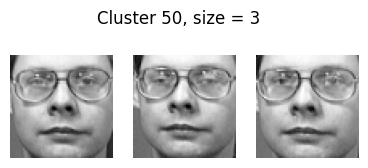

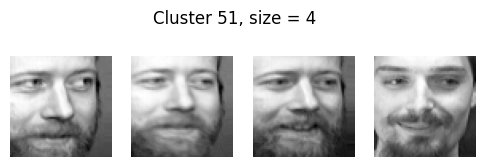

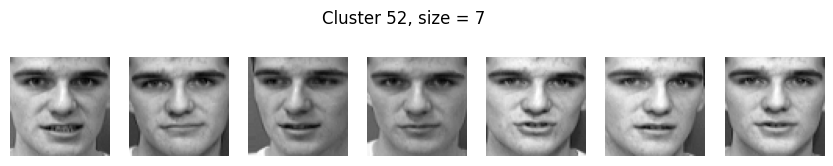

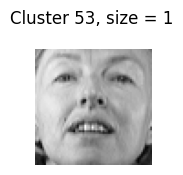

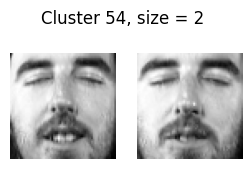

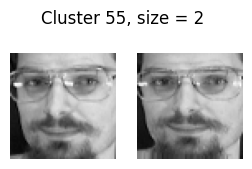

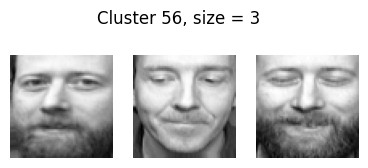

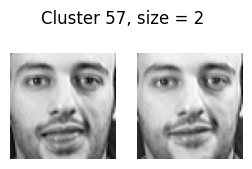

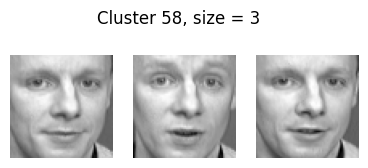

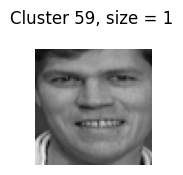

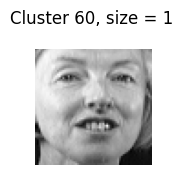

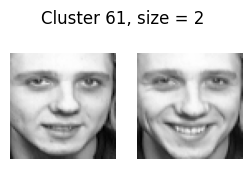

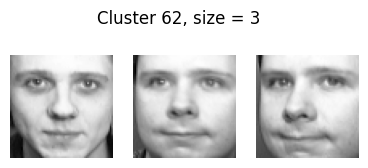

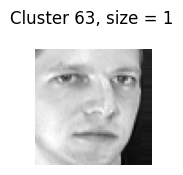

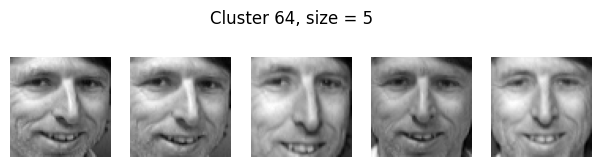

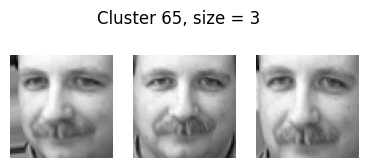

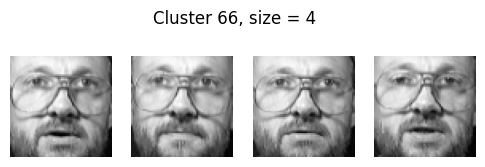

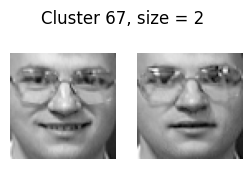

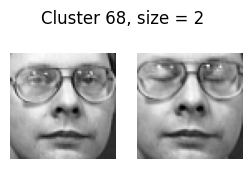

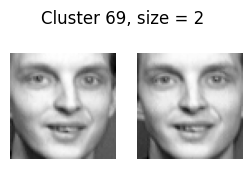

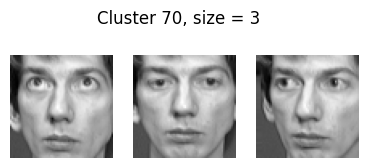

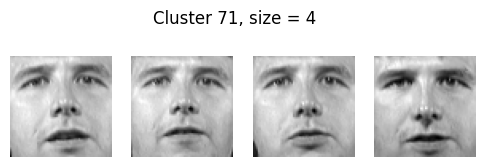

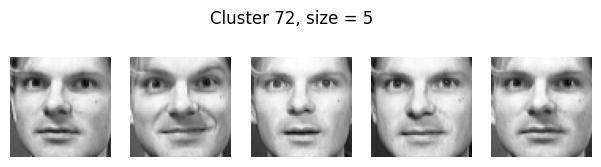

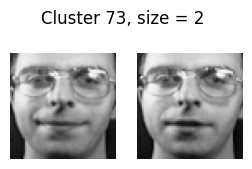

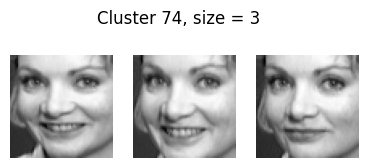

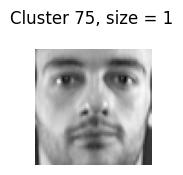

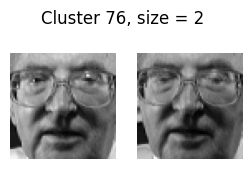

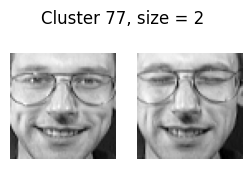

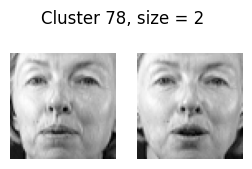

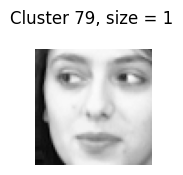

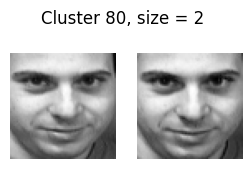

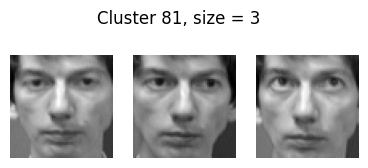

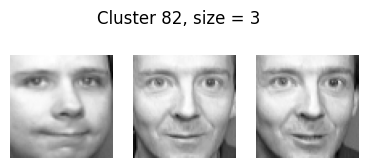

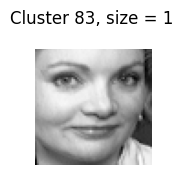

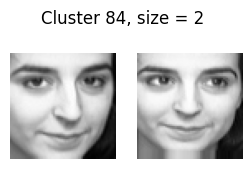

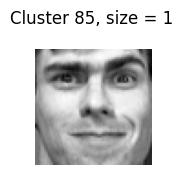

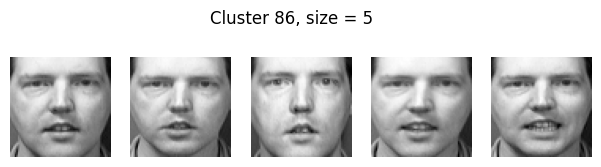

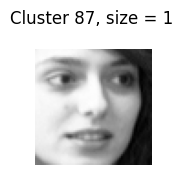

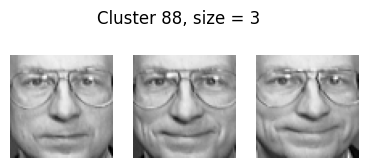

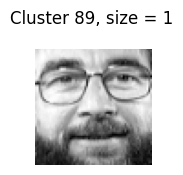

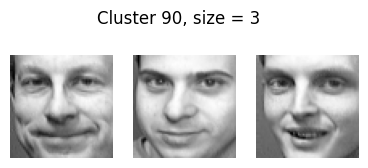

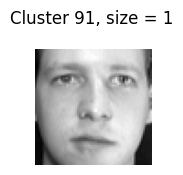

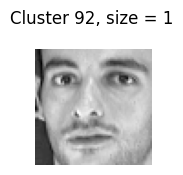

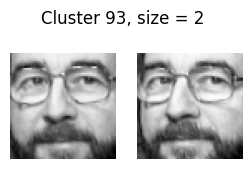

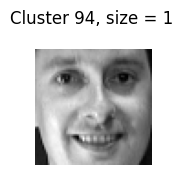

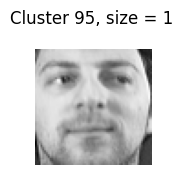

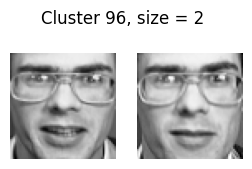

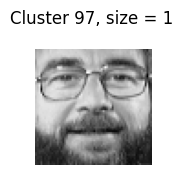

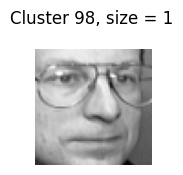

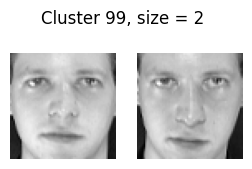

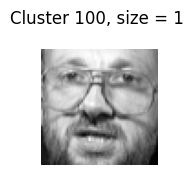

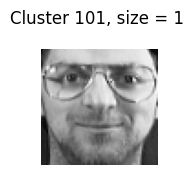

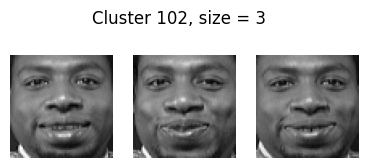

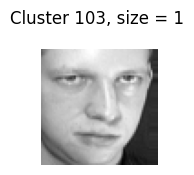

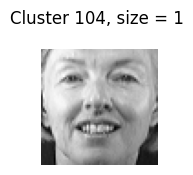

In [9]:
def plot_faces_by_cluster(X, cluster_labels, n_clusters, images_per_cluster=10):
    for cluster_id in range(n_clusters):
        cluster_indices = np.where(cluster_labels == cluster_id)[0]
        
        if len(cluster_indices) == 0:
            continue
        
        n_images = min(len(cluster_indices), images_per_cluster)
        
        plt.figure(figsize=(1.5 * n_images, 2))
        
        for i, index in enumerate(cluster_indices[:n_images]):
            plt.subplot(1, n_images, i + 1)
            plt.imshow(X[index].reshape(64, 64), cmap="gray")
            plt.axis("off")
        
        plt.suptitle(f"Cluster {cluster_id}, size = {len(cluster_indices)}")
        plt.show()

plot_faces_by_cluster(X_train, best_cluster_labels, best_k, images_per_cluster=10)

### Cluster Quality Notes
After visualizing the faces in each cluster, many clusters contain some faces that do not look very similar to the others. This shows that k-Means does not perfectly separate the actual people in the dataset.

However, the clustering still works reasonably well for some faces with strong visual features. For example, faces with distinctive facial features, glasses, beards, or similar lighting and head positions are often grouped more clearly.

Overall, k-Means can capture some visual similarities among the face images, especially when the faces have strong and recognizable features. However, the clustering result is not perfect, and some clusters still contain mixed or visually different faces.


## Classification on PCA Features
Continue to use the reduced features based on PCA in (a). Train a random forest classifier `RandomForestClassifier(n_estimators=150, random_state=42)` and a histogram-based gradient boosting classifier using `HistGradientBoostingClassifier(max_iter=200, random_state=42, early_stopping=True, validation_fraction=0.2)` to predict which person is represented in each picture, and evaluate it on the validation set. For the gradient boosting classifier state the optimal number of iterations from early stopping. State which of the two models is better.


**Implementation:**


In [10]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Random Forest classifier
rf_clf = RandomForestClassifier(n_estimators=150, random_state=42)

rf_clf.fit(X_train_pca, y_train)

y_valid_pred_rf = rf_clf.predict(X_valid_pca)
rf_accuracy = accuracy_score(y_valid, y_valid_pred_rf)

print("Random Forest validation accuracy:", rf_accuracy)

Random Forest validation accuracy: 0.9333333333333333


In [11]:
# Histogram-based Gradient Boosting classifier
hgb_clf = HistGradientBoostingClassifier(
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.2
)

hgb_clf.fit(X_train_pca, y_train)

y_valid_pred_hgb = hgb_clf.predict(X_valid_pca)
hgb_accuracy = accuracy_score(y_valid, y_valid_pred_hgb)

print("HistGradientBoosting validation accuracy:", hgb_accuracy)
print("Optimal number of iterations:", hgb_clf.n_iter_)

HistGradientBoosting validation accuracy: 0.7666666666666667
Optimal number of iterations: 85


### Classifier Comparison Notes
the Random Forest classifier achieved a validation accuracy of **0.9333**, while the Histogram-based Gradient Boosting classifier achieved a validation accuracy of **0.7667**. Based on the validation accuracy, the **Random Forest classifier performed better** than the Histogram-based Gradient Boosting classifier on the validation set.


## k-Means Features for Classification

Continuing on from the classifier comparison, the random forest classifier is used. Next, k-Means is used as a dimensionality reduction tool before training a classifier. Search for the number of clusters $k\in\{5,10,15,\dots,145\}$ that allows the classifier to get the best performance on the validation set. The validation performance is recorded, then the k-Means features are appended to the original features and the search for the best number of clusters is repeated.


**Implementation:**


In [12]:
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

k_range = range(5, 150, 5)

kmeans_rf_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    X_train_kmeans = kmeans.fit_transform(X_train_pca)
    X_valid_kmeans = kmeans.transform(X_valid_pca)
    
    rf_clf = RandomForestClassifier(n_estimators=150, random_state=42)
    rf_clf.fit(X_train_kmeans, y_train)
    
    y_valid_pred = rf_clf.predict(X_valid_kmeans)
    score = accuracy_score(y_valid, y_valid_pred)
    
    kmeans_rf_scores.append(score)

best_k_kmeans = list(k_range)[np.argmax(kmeans_rf_scores)]
best_kmeans_score = max(kmeans_rf_scores)

print("Best k using k-Means:", best_k_kmeans)
print("Best validation accuracy using k-Means:", best_kmeans_score)

Best k using k-Means: 110
Best validation accuracy using k-Means: 0.8333333333333334


In [13]:
# Append k-Means features to the PCA features
combined_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    X_train_kmeans = kmeans.fit_transform(X_train_pca)
    X_valid_kmeans = kmeans.transform(X_valid_pca)
    
    X_train_combined = np.c_[X_train_pca, X_train_kmeans]
    X_valid_combined = np.c_[X_valid_pca, X_valid_kmeans]
    
    rf_clf = RandomForestClassifier(n_estimators=150, random_state=42)
    rf_clf.fit(X_train_combined, y_train)
    
    y_valid_pred = rf_clf.predict(X_valid_combined)
    score = accuracy_score(y_valid, y_valid_pred)
    
    combined_scores.append(score)

best_k_combined = list(k_range)[np.argmax(combined_scores)]
best_combined_score = max(combined_scores)

print("Best k using PCA features + k-Means features:", best_k_combined)
print("Best validation accuracy using combined features:", best_combined_score)

Best k using PCA features + k-Means features: 5
Best validation accuracy using combined features: 0.9416666666666667


### Cluster Feature Notes
Using only the k-Means features, the best number of clusters was **k = 110**, and the validation accuracy was **0.8333**. This result is lower than the Random Forest model using only the PCA-reduced features from 3(b), which had an accuracy of **0.9333**.

After combining the PCA features with the k-Means features, the best number of clusters was **k = 5**, and the validation accuracy increased to **0.9417**. This is slightly better than using only the PCA features.

Overall, using k-Means features alone did not improve the model, but adding the k-Means features to the PCA features slightly improved the Random Forest classifier. Therefore, the best result was achieved by using **PCA features + k-Means features** together.


# Finding Regimes in Time Series

## Clustering Inflation and Unemployment Regimes
This section obtains the daily values of the CPI and unemployment rate from FRED up to 2023-01-01 and then converts the CPI into the yearly inflation rate `inf_data`. The code below reads public FRED CSV endpoints directly and does not require local credentials.


**Note:** A compatibility issue can occur when importing `pandas_datareader` with newer Python versions. This notebook uses `pandas.read_csv()` with FRED CSV links to retrieve the data directly. This method avoids the package compatibility problem and produces the same unemployment and CPI data needed for the analysis.


In [20]:
import pandas as pd

unemp_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE"
cpi_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL"

unemp_data = pd.read_csv(
    unemp_url,
    parse_dates=["observation_date"],
    index_col="observation_date"
)

cpi_data = pd.read_csv(
    cpi_url,
    parse_dates=["observation_date"],
    index_col="observation_date"
)

unemp_data = unemp_data.loc["1945-01-01":"2023-01-01"]
cpi_data = cpi_data.loc["1945-01-01":"2023-01-01"]

inf_data = (cpi_data / cpi_data.shift(12) - 1).iloc[12:]

data = pd.concat([inf_data, unemp_data], axis=1)
data.columns = ["Inflation", "UNRATE"]
data = data.dropna()

data.head()

,Inflation,UNRATE
observation_date,,
1948-01-01,0.102421,3.4
1948-02-01,0.094820,3.8
1948-03-01,0.068182,4.0
1948-04-01,0.082727,3.9
1948-05-01,0.093850,3.5


The data is split into a training set (before Jan 2005, using `data[:"2005-1-1"]` for instance) and a test set (Jan 2005 and after). Now, ignore the time aspect of the training set by treating it as a 2-dimensional dataset. K-means is used to divide the training set into a number of clusters called **regimes**. To find the number of regimes (clusters) $k\in\{2,3,\dots,10\}$: (i) plot inertia, (ii) plot silhouette scores, (iii) plot silhouette diagrams for $k\in\{2,3,\dots,10\}$. The notebook compares these diagnostics to choose the number of regimes. Recall that it is useful to use a standard scaler before applying k-means.


**Implementation:**


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

In [22]:
# Training set: before Jan 2005
data_train = data.loc[:"2004-12-01"]

# Test set: Jan 2005 and after
data_test = data.loc["2005-01-01":]

print(data_train.shape)
print(data_test.shape)

(684, 2)
(217, 2)


In [23]:
# Standardize the training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(data_train)
X_test_scaled = scaler.transform(data_test)

In [24]:
# Run k-Means for k = 2 to 10
k_range = range(2, 11)

inertias = []
silhouette_scores = []
kmeans_models = {}

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, labels))
    kmeans_models[k] = kmeans

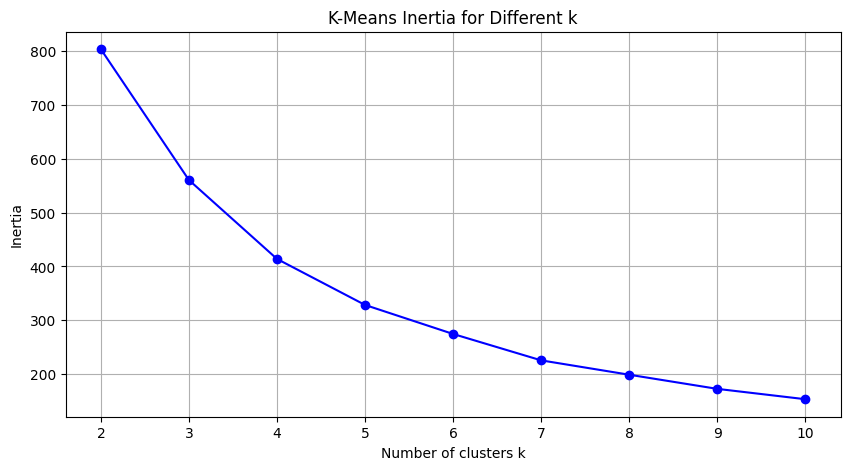

In [25]:
# (i) Plot inertia
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, "bo-")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("K-Means Inertia for Different k")
plt.grid(True)
plt.show()

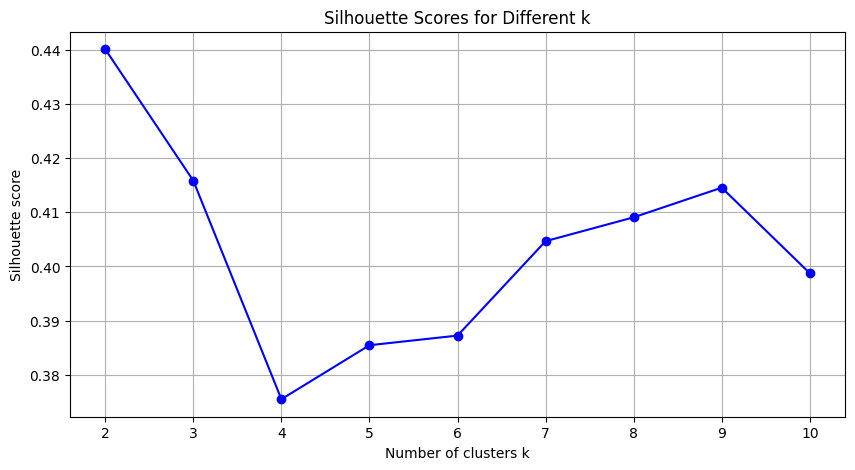

Best k based on silhouette score: 2
Best silhouette score: 0.4401369799794077


In [26]:
# (ii) Plot silhouette scores
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, "bo-")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette Scores for Different k")
plt.grid(True)
plt.show()

best_k = list(k_range)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print("Best k based on silhouette score:", best_k)
print("Best silhouette score:", best_score)

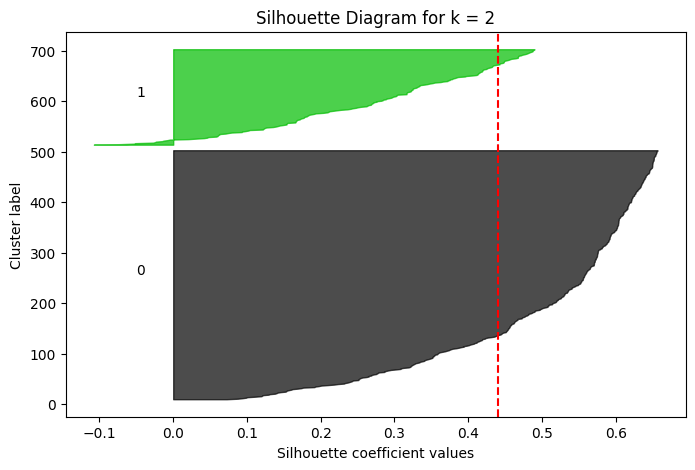

k = 2, silhouette score = 0.4401369799794077


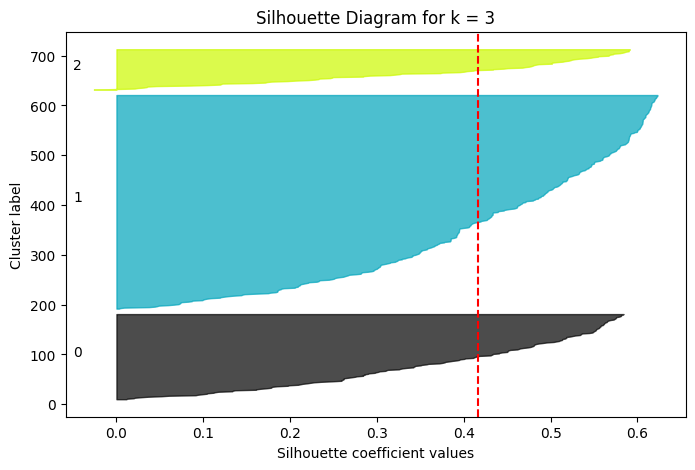

k = 3, silhouette score = 0.41584219181630483


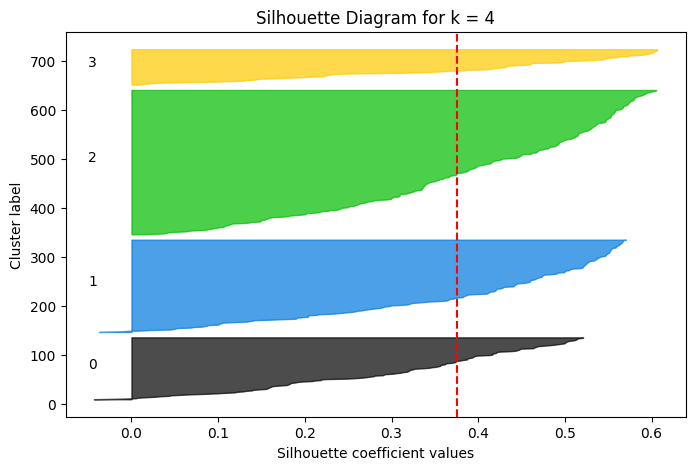

k = 4, silhouette score = 0.3754673424587641


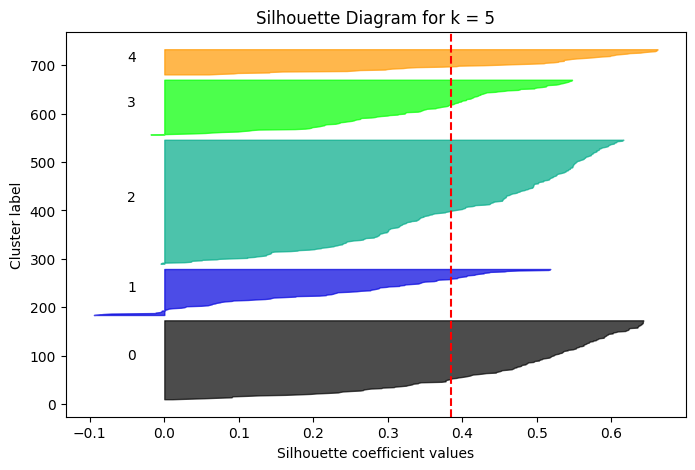

k = 5, silhouette score = 0.3854454358233735


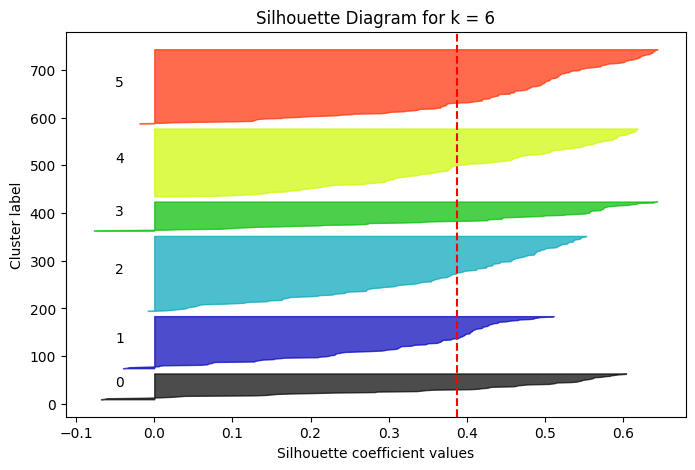

k = 6, silhouette score = 0.3872245953759971


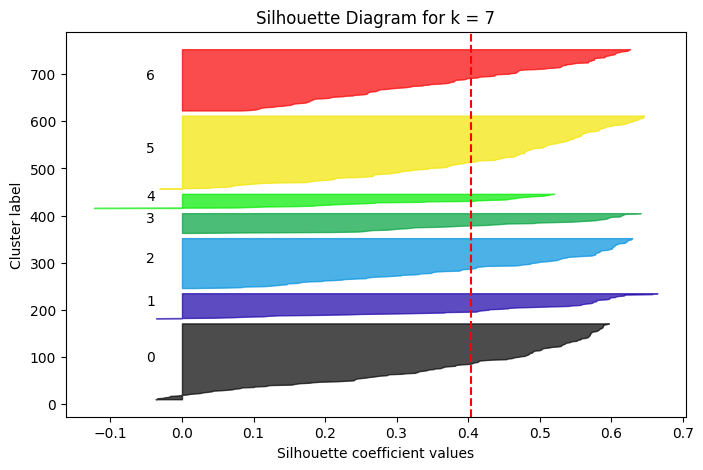

k = 7, silhouette score = 0.4046715998610709


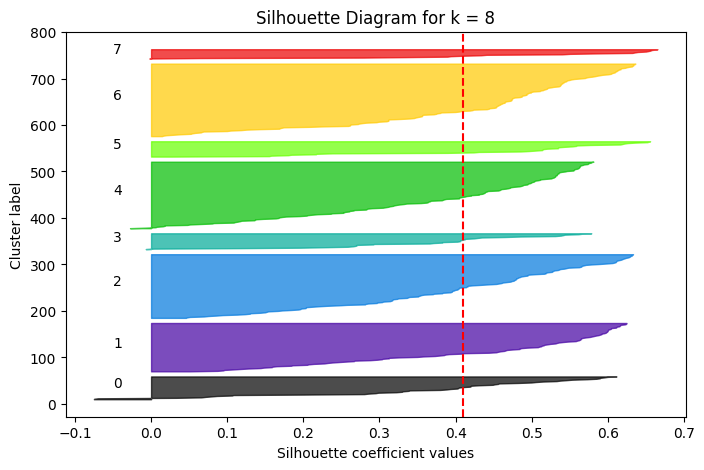

k = 8, silhouette score = 0.4090774472674582


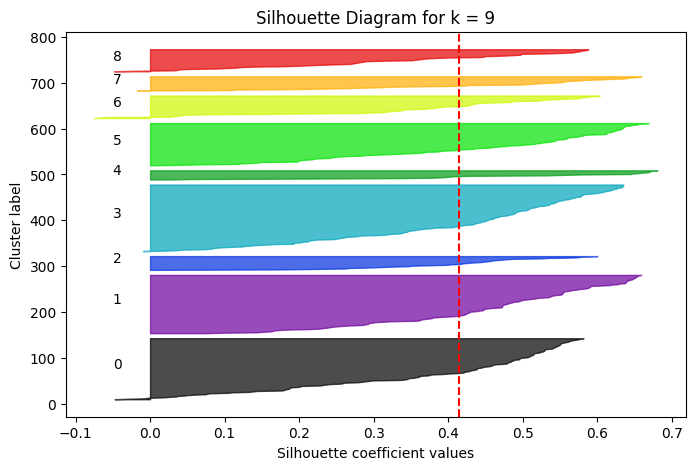

k = 9, silhouette score = 0.41455778229499557


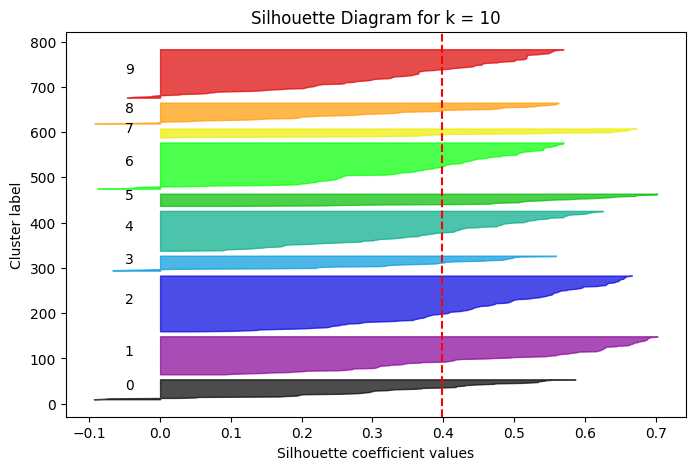

k = 10, silhouette score = 0.39874385692444736


In [27]:
# (iii) Plot silhouette diagrams for k = 2 ~ 10
def plot_silhouette_diagram(X, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    silhouette_avg = silhouette_score(X, labels)
    sample_silhouette_values = silhouette_samples(X, labels)
    
    plt.figure(figsize=(8, 5))
    y_lower = 10
    
    for i in range(k):
        ith_cluster_values = sample_silhouette_values[labels == i]
        ith_cluster_values.sort()
        
        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / k)
        
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )
        
        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.xlabel("Silhouette coefficient values")
    plt.ylabel("Cluster label")
    plt.title(f"Silhouette Diagram for k = {k}")
    plt.show()
    
    print(f"k = {k}, silhouette score = {silhouette_avg}")

for k in k_range:
    plot_silhouette_diagram(X_train_scaled, k)

In [28]:
best_k = list(k_range)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print("Best k based on silhouette score:", best_k)
print("Best silhouette score:", best_score)

Best k based on silhouette score: 2
Best silhouette score: 0.4401369799794077


The selected setting uses **2 regimes**. The silhouette score is highest when **k = 2**, with a score of **0.4401**. Although inertia keeps decreasing as k increases, this is expected and does not show a clear better choice. Therefore, based mainly on the silhouette score, **2 regimes** is the best choice.


## Regime Centroids and Training/Test Assignments
Report the centroid of the regimes in (a). For the training set, plot the inflation rate (x-axis) vs unemployment rate (y-axis) after these features have been standardized, and show the regimes and centroids in the plot. For the test set, plot time series of the inflation rate and unemployment rate (the original series before standardization), and show the regimes on the plot. The regimes can be shown using time series (line graphs) of the centroid for each of two series for instance, and the following code can be used, where `best_mod_pred` is the prediction on the test set from the best model.


**Implementation:**


In [31]:
# Fit the final model using the chosen k
best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
best_kmeans.fit(X_train_scaled)

best_mod_pred = best_kmeans.predict(X_test_scaled)
clusters = scaler.inverse_transform(best_kmeans.cluster_centers_)

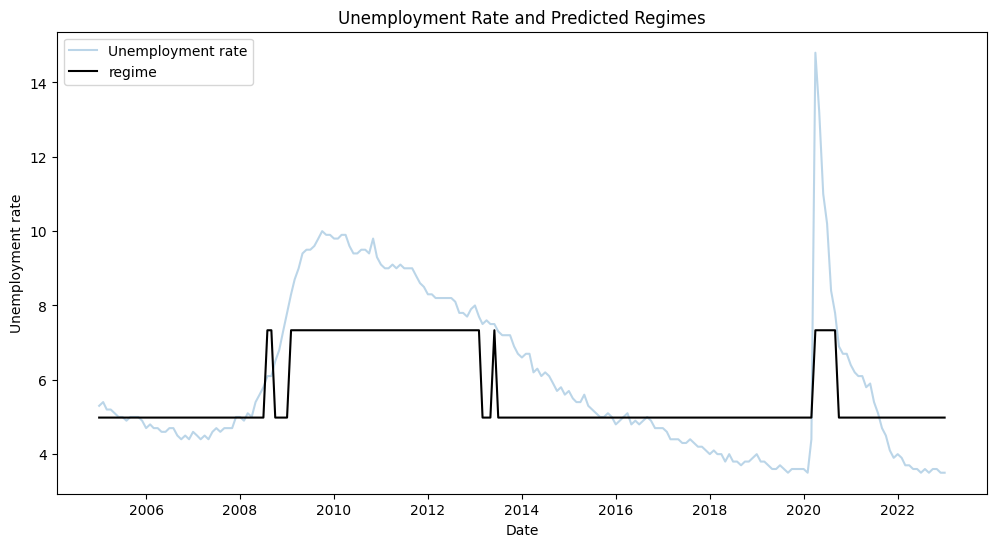

In [37]:
# Create a DataFrame for plotting
regimes_test = pd.DataFrame(data_test.iloc[:, 1]).assign(
    regime=clusters[best_mod_pred][:, 1]
)

regimes_test.columns = ["Unemployment", "regime"]

plt.figure(figsize=(12, 6))
plt.plot(regimes_test["Unemployment"], label="Unemployment rate", alpha=.3)
plt.plot(regimes_test["regime"], "-k", label="regime")
plt.title("Unemployment Rate and Predicted Regimes")
plt.xlabel("Date")
plt.ylabel("Unemployment rate")
plt.legend()
plt.show()

## Markov Transition Matrices for Regimes


A regime-switching model is a probabilistic model that governs how regime transitions take place. A very simple regime-switching model is a Markov chain. Here, we assume that the next month's regime depends on the current regime. In other words, all we need to know are the **transition probabilities** $p_{i,j} = \mathbb{P}(X_{t+1}=j|X_t=i)$, where $X_t$ is the regime at day $t$. The time series of regimes from the training set is used to estimate these transition probabilities:
\begin{align*}
    p_{i,j} = \frac{\mathbb{P}(X_{t+1}=j \text{ and } X_t=i)}{\mathbb{P}(X_t=i)}\approx \frac{\text{number of transition from regime $i$ to $j$}}{\text{number of transition from regime $i$}}
\end{align*}
Next, the fitted regime-switching workflow is checked on the test set. The transition probabilities are calculated using the test set. The fitted k-means clusterer is reused to predict regimes in the test set. The estimation of transition probabilities is then repeated on the test set.

Note: Depending on the selected value of $k$, it is possible that some $p_{i,j}$ cannot be estimated due to  having no transitions from regime $i$.


**Implementation:**


In [42]:
# Predict regimes for the training set and test set
train_regimes = best_kmeans.predict(X_train_scaled)
test_regimes = best_kmeans.predict(X_test_scaled)

In [ ]:
# Function to calculate transition probabilities
def transition_matrix(regimes, k):
    counts = np.zeros((k, k))
    
    for t in range(len(regimes) - 1):
        current_regime = regimes[t]
        next_regime = regimes[t + 1]
        counts[current_regime, next_regime] += 1
    
    probabilities = counts / counts.sum(axis=1, keepdims=True)
    
    return counts, probabilities

In [44]:
# Calculate transition probabilities for training set
train_counts, train_transition_probs = transition_matrix(train_regimes, best_k)

print("Training transition counts:")
print(train_counts)

print("Training transition probabilities:")
print(train_transition_probs)

Training transition counts:
[[489.   4.]
 [  4. 186.]]
Training transition probabilities:
[[0.99188641 0.00811359]
 [0.02105263 0.97894737]]


In [45]:
# Calculate transition probabilities for test set
test_counts, test_transition_probs = transition_matrix(test_regimes, best_k)

print("Test transition counts:")
print(test_counts)

print("Test transition probabilities:")
print(test_transition_probs)

Test transition counts:
[[154.   4.]
 [  4.  54.]]
Test transition probabilities:
[[0.97468354 0.02531646]
 [0.06896552 0.93103448]]


### Regime Persistence Notes
The transition matrices show that both regimes are highly persistent. In the training set, Regime 0 stays in Regime 0 with probability **0.9919**, and Regime 1 stays in Regime 1 with probability **0.9789**.

In the test set, Regime 0 also remains very persistent, with a staying probability of **0.9747**. Regime 1 has a lower but still high staying probability of **0.9310**.

Overall, the economy tends to remain in the same regime from one month to the next, and regime switches are relatively rare.
